In [2]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle

In [3]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [4]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [5]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
# import pickle

# # Save
# with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "wb") as f:
#     pickle.dump(gmm_cache, f)
    
# Load
# with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
#     gmm_cache = pickle.load(f)

In [6]:
no_aug_synth_ds = synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [7]:
train_ds = filter_by_elev(synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds  = filter_by_elev(meas_ds, {17})

In [8]:
ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

In [8]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

train_loss = []
val_loss = []
train_acc =[]
val_acc = []

for i, seed in enumerate(seed_lst):
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
    # scheduler = OneCycleLR(
    #     optimizer, 
    #     max_lr = 2.5e-4, 
    #     steps_per_epoch = len(dataloaders["train"]), 
    #     epochs = 100
    #     )
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "val_loss" : [],
        "train_acc": [],
        "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.7f} Acc: {epoch_acc:.7f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

        if epoch == 0:
            torch.save(copy.deepcopy(model.state_dict()), os.path.join(workspace, f"weights/SSR/SSR_w_noise/rn18_run{i}_b16_epoch0.pth"))
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/SSR_w_noise/rn18_run{i}_b16.pth"))

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 1.9495283 Acc: 0.2990074
val Loss: 2.3944735 Acc: 0.1240695
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 1.0268128 Acc: 0.6302730
val Loss: 1.0404278 Acc: 0.6736973
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.4745620 Acc: 0.8374690
val Loss: 1.3058315 Acc: 0.6004963
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.3998000 Acc: 0.8610422
val Loss: 0.7125736 Acc: 0.7828784
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.1779034 Acc: 0.9516129
val Loss: 0.6329532 Acc: 0.8014888
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.1323583 Acc: 0.9615385
val Loss: 0.7720843 Acc: 0.7630273
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.1288696 Acc: 0.9640199
val Loss: 0.7771069 Acc: 0.7766749
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.1003408 Acc: 0.9714640
val Loss: 0.5646852 Acc: 0.8399504
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 0.1053334 Acc: 0.9751861
val Loss: 0.7107915 Acc: 0.8213400
Epoch 8 LR: 0.0002985050
Epoc

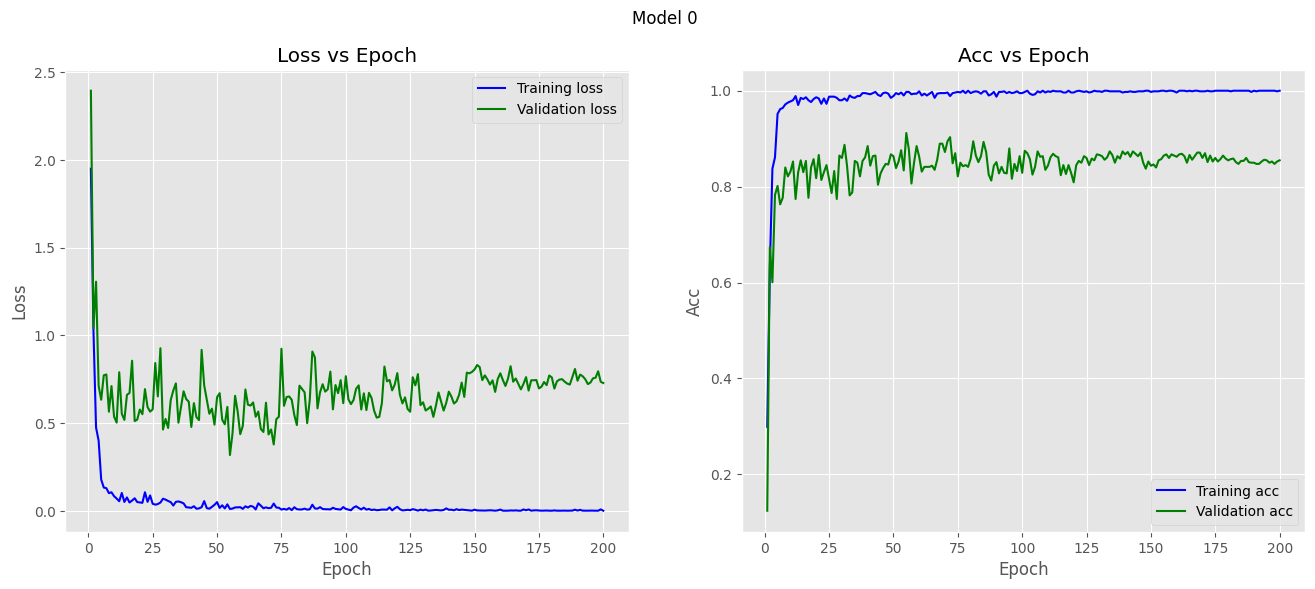

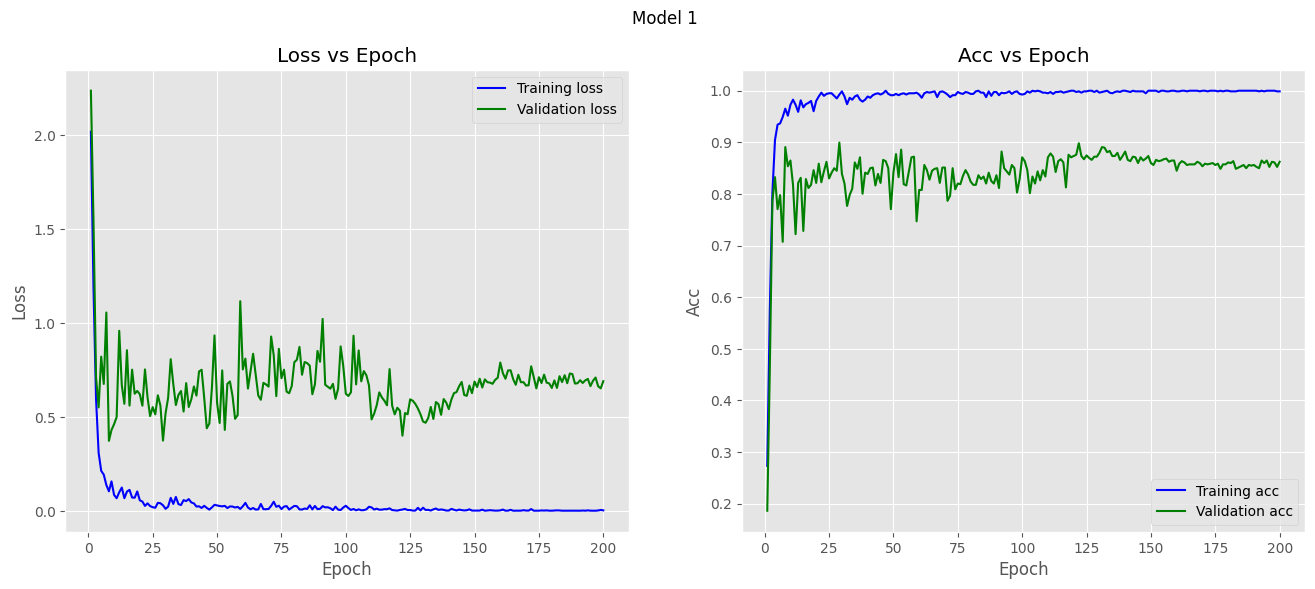

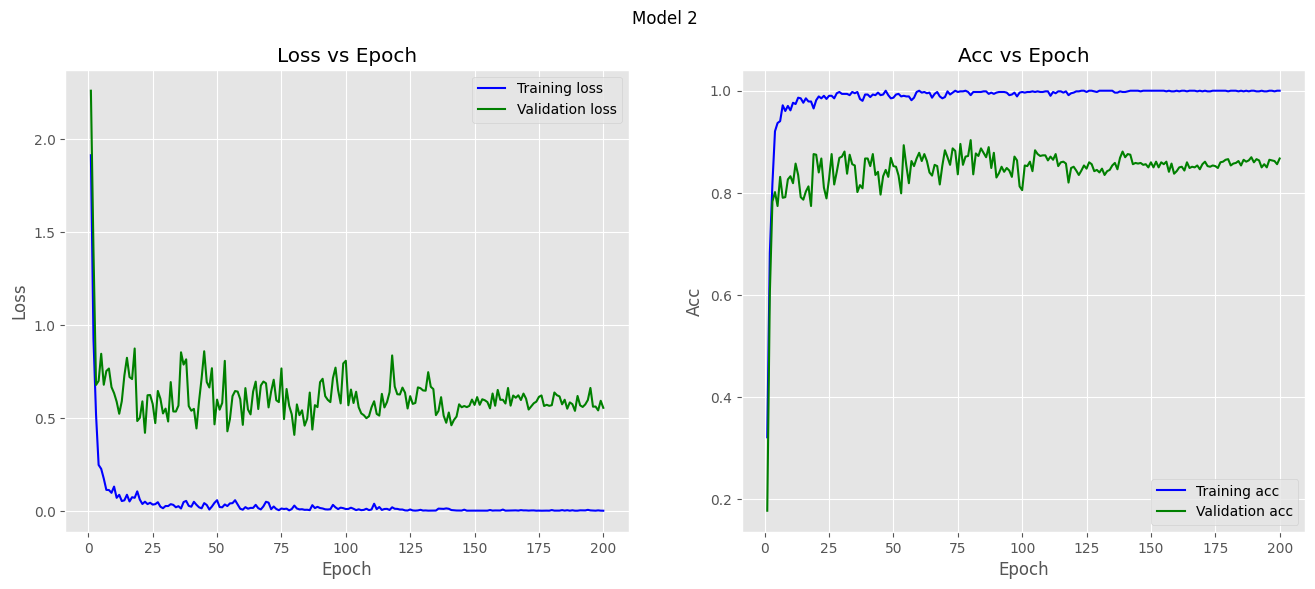

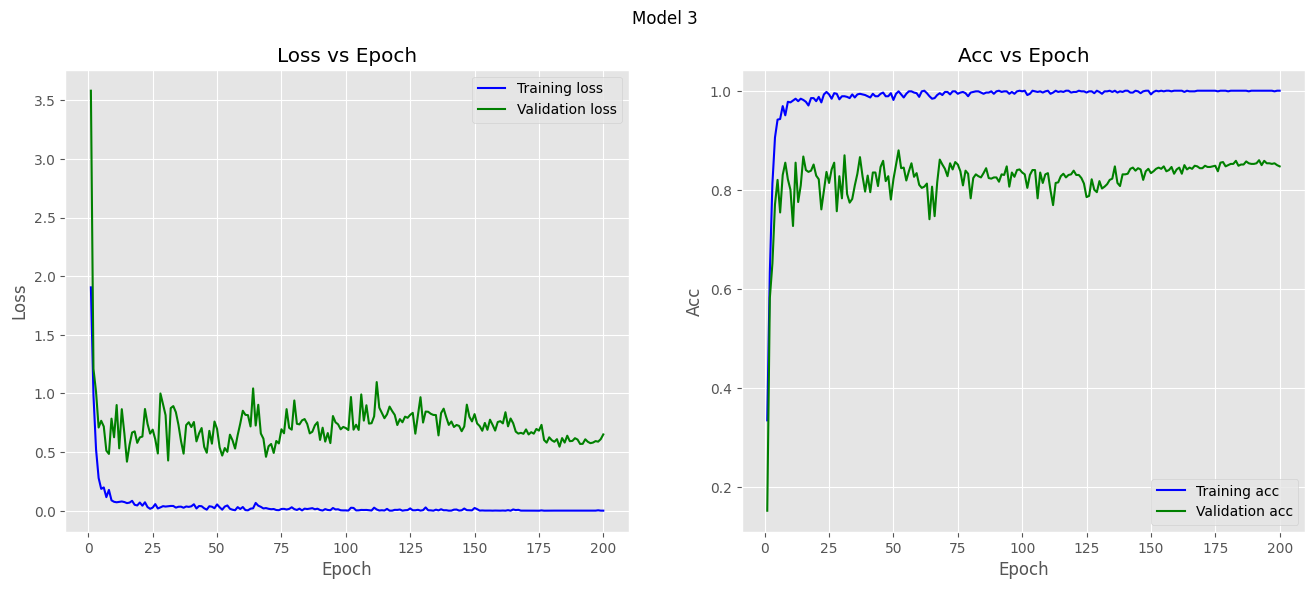

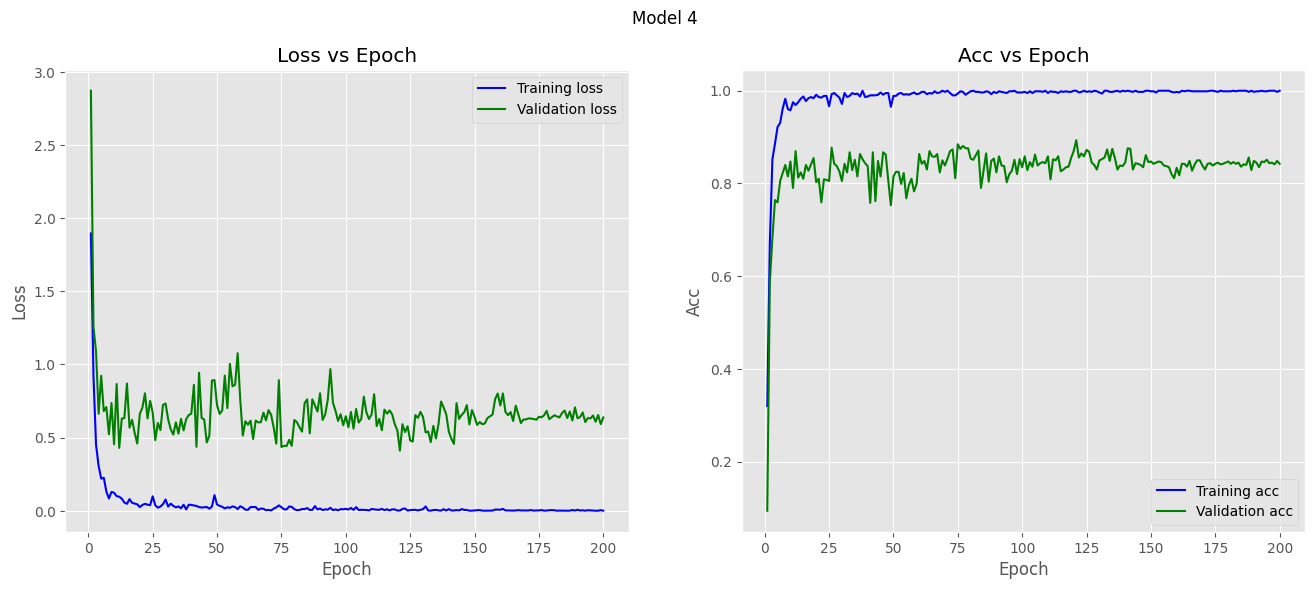

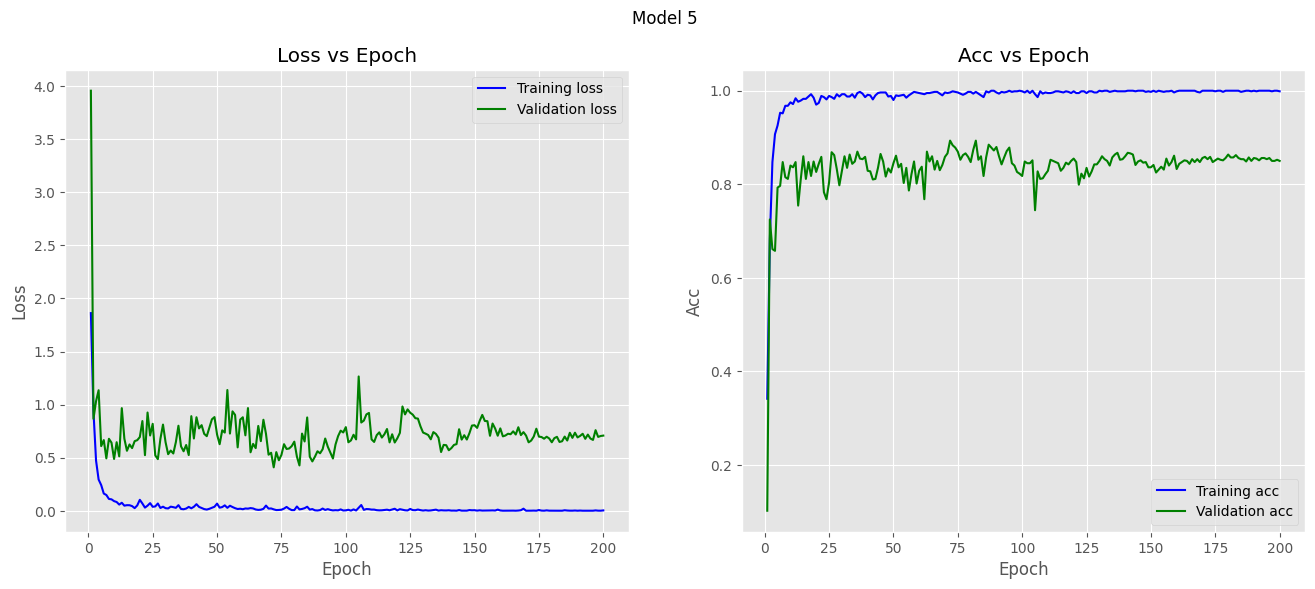

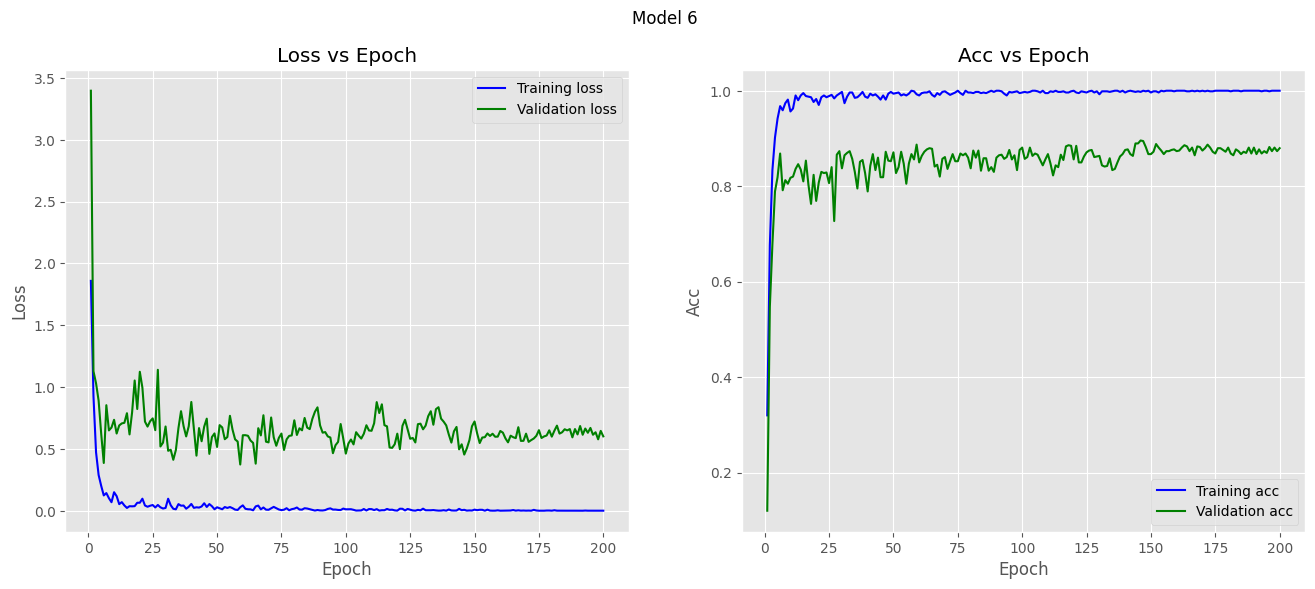

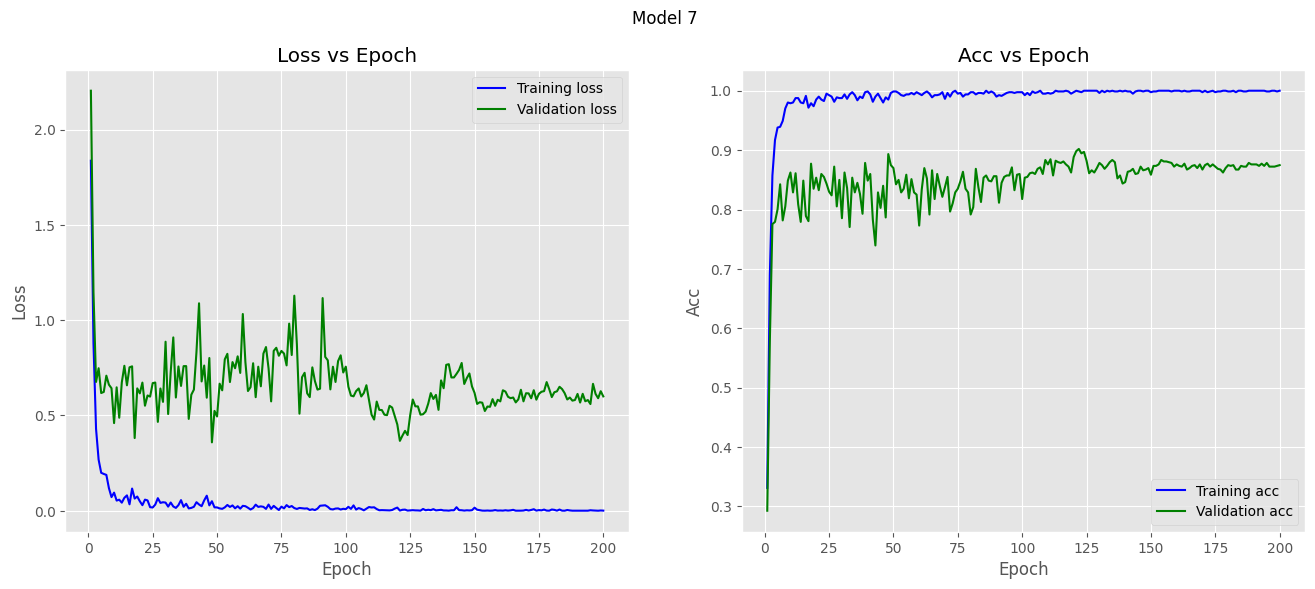

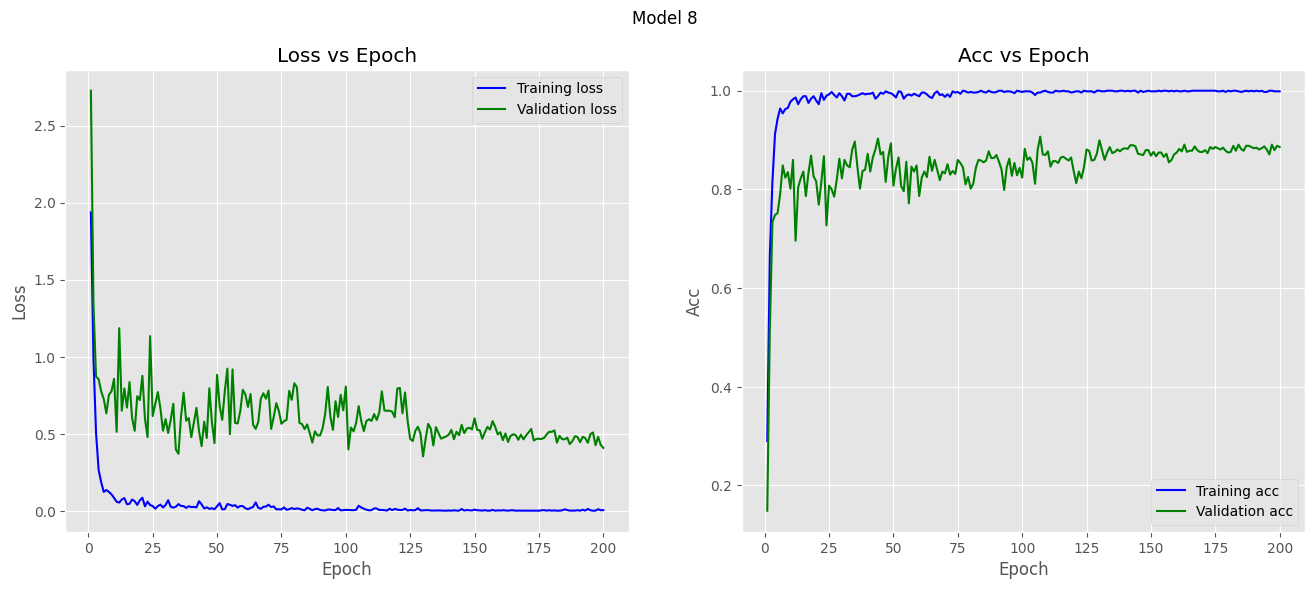

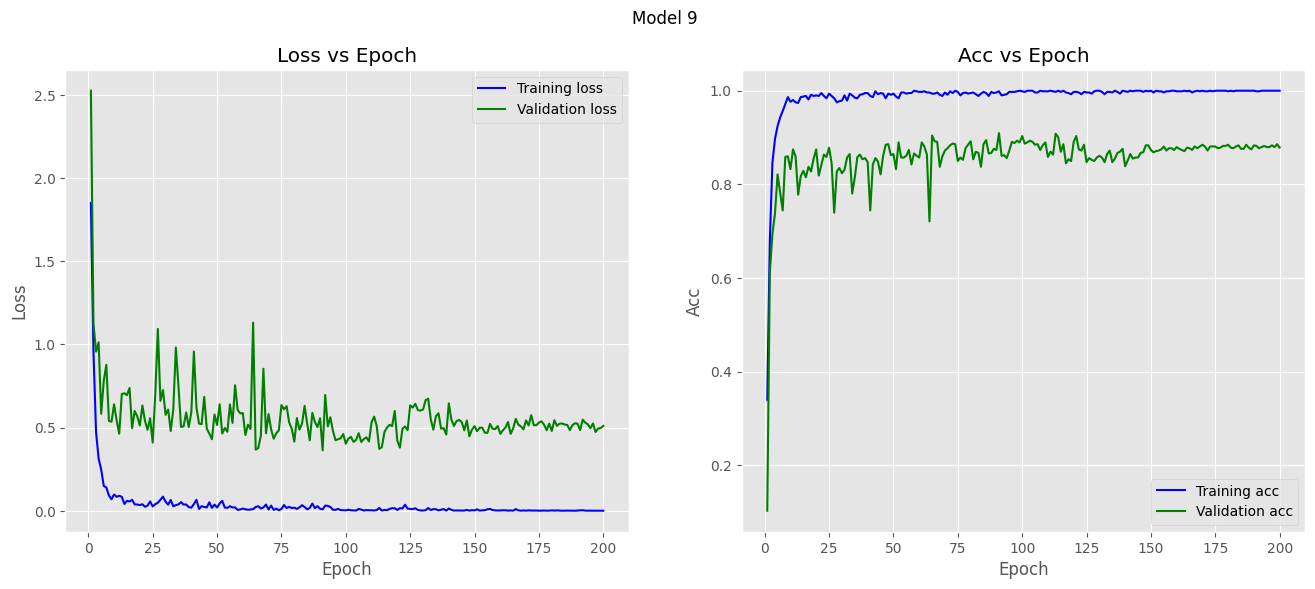

In [9]:
row, col = train_loss.shape

for i in range(row):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Model {i}")
        plt.show()

# Measured 17 Only

In [8]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run{i}_b16_epoch0.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.0965
Evaluating Run 1
Test Accuracy: 0.2430
Evaluating Run 2
Test Accuracy: 0.2171
Evaluating Run 3
Test Accuracy: 0.2078
Evaluating Run 4
Test Accuracy: 0.1039
Evaluating Run 5
Test Accuracy: 0.1224
Evaluating Run 6
Test Accuracy: 0.1503
Evaluating Run 7
Test Accuracy: 0.2987
Evaluating Run 8
Test Accuracy: 0.1763
Evaluating Run 9
Test Accuracy: 0.0649


In [9]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run{i}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.8998
Evaluating Run 1
Test Accuracy: 0.9351
Evaluating Run 2
Test Accuracy: 0.9314
Evaluating Run 3
Test Accuracy: 0.9221
Evaluating Run 4
Test Accuracy: 0.8627
Evaluating Run 5
Test Accuracy: 0.9165
Evaluating Run 6
Test Accuracy: 0.9351
Evaluating Run 7
Test Accuracy: 0.9462
Evaluating Run 8
Test Accuracy: 0.9035
Evaluating Run 9
Test Accuracy: 0.9388


In [10]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 86.2709
Max: 94.6197
Avg, Std: 91.9109, 2.3646


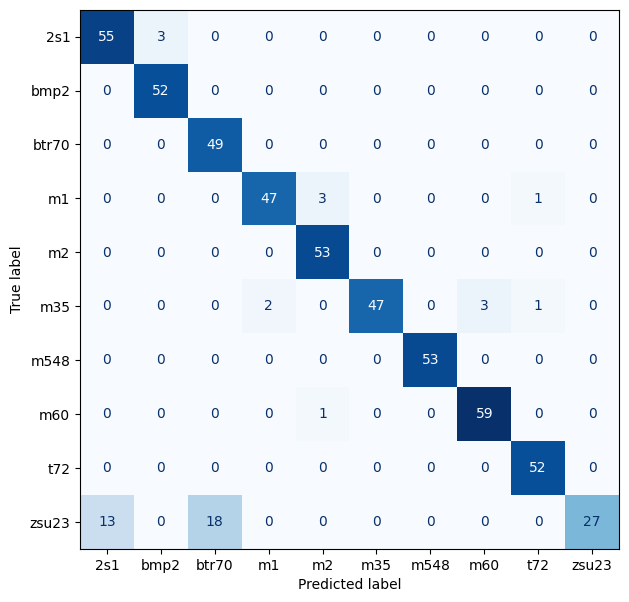

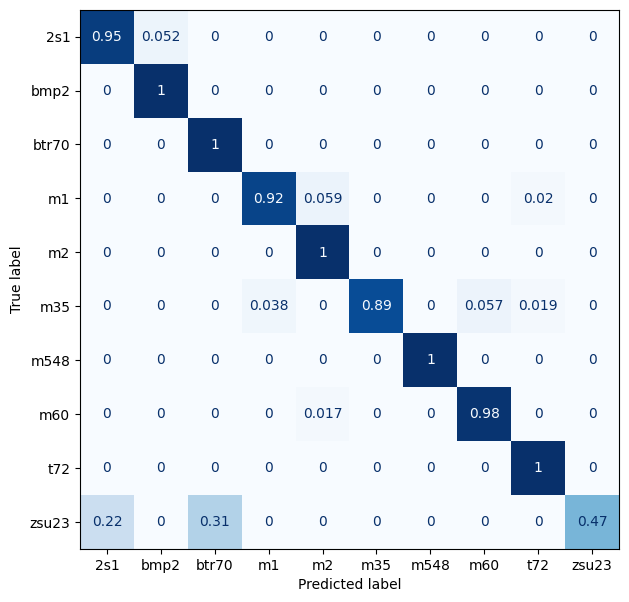

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run5_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()
plt.show()

In [9]:
combined_ds = ConcatDataset([filter_by_elev(no_aug_synth_ds, {14, 15, 16}), filter_by_elev(meas_ds, {17})])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

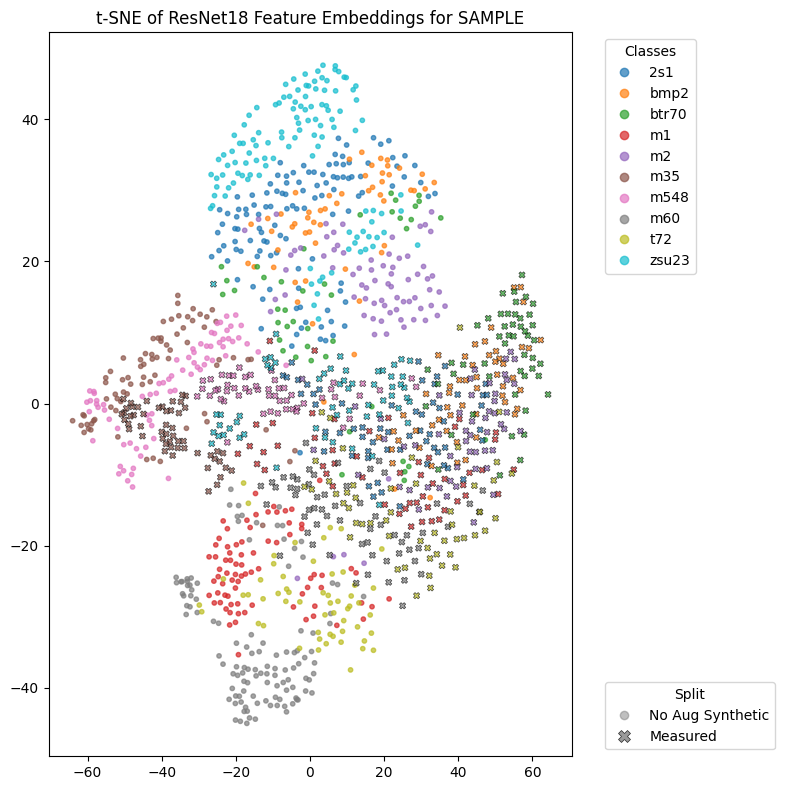

In [10]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run5_b16_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

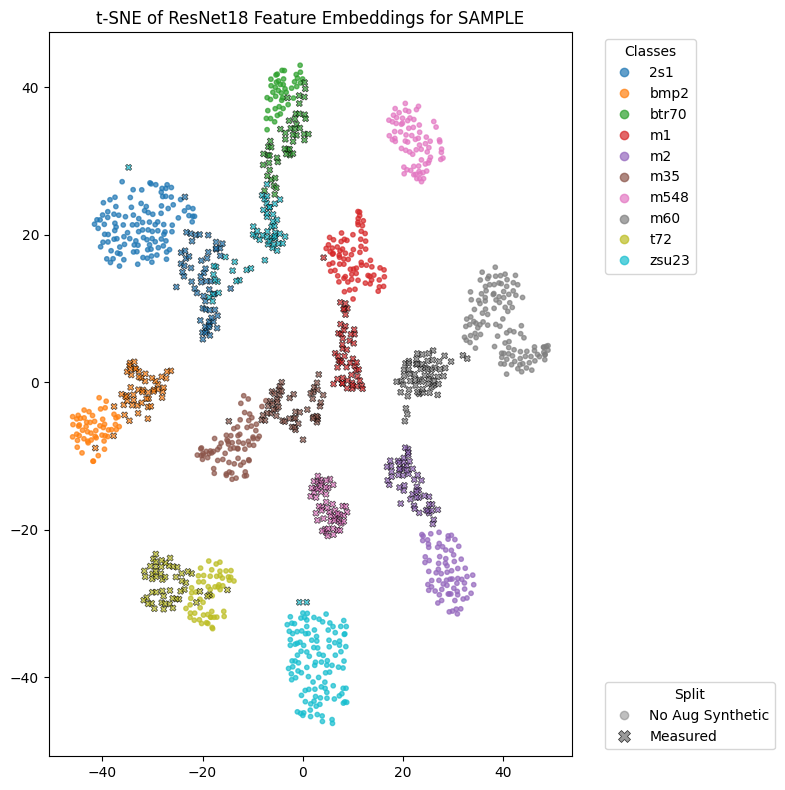

In [11]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run5_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-26 02:48:28.679] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


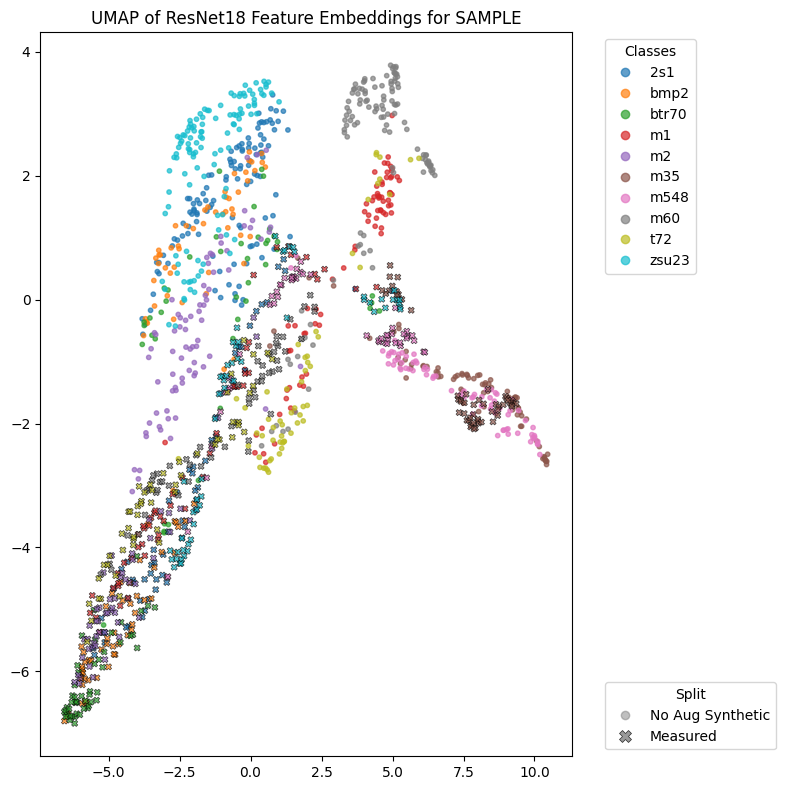

In [12]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run5_b16_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-26 02:48:46.422] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


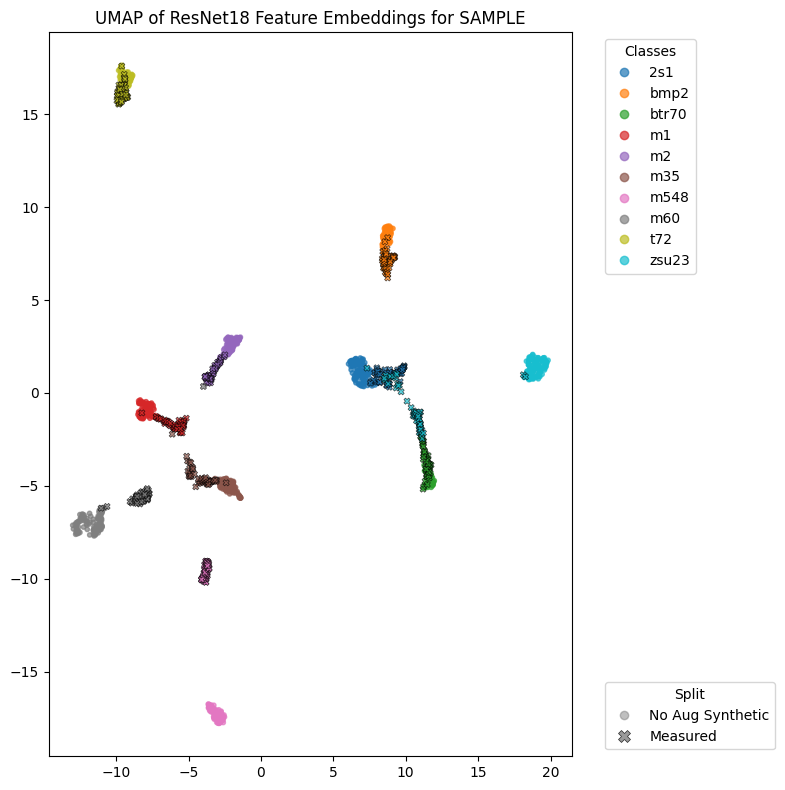

In [13]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run5_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

# Measured 14, 15, 16 and 17

In [7]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run{i}_b16_epoch0.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.1130
Evaluating Run 1
Test Accuracy: 0.2089
Evaluating Run 2
Test Accuracy: 0.1933
Evaluating Run 3
Test Accuracy: 0.1747
Evaluating Run 4
Test Accuracy: 0.0981
Evaluating Run 5
Test Accuracy: 0.1100
Evaluating Run 6
Test Accuracy: 0.1323
Evaluating Run 7
Test Accuracy: 0.2952
Evaluating Run 8
Test Accuracy: 0.1599
Evaluating Run 9
Test Accuracy: 0.0877


In [8]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run{i}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.8729
Evaluating Run 1: Seed 42
Test Accuracy: 0.8914
Evaluating Run 2: Seed 100
Test Accuracy: 0.8929
Evaluating Run 3: Seed 123
Test Accuracy: 0.8773
Evaluating Run 4: Seed 666
Test Accuracy: 0.8506
Evaluating Run 5: Seed 777
Test Accuracy: 0.8766
Evaluating Run 6: Seed 849
Test Accuracy: 0.9019
Evaluating Run 7: Seed 1000
Test Accuracy: 0.9033
Evaluating Run 8: Seed 1111
Test Accuracy: 0.8929
Evaluating Run 9: Seed 1234
Test Accuracy: 0.9026


In [9]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 85.0558
Max: 90.3346
Avg, Std: 88.6245, 1.5957


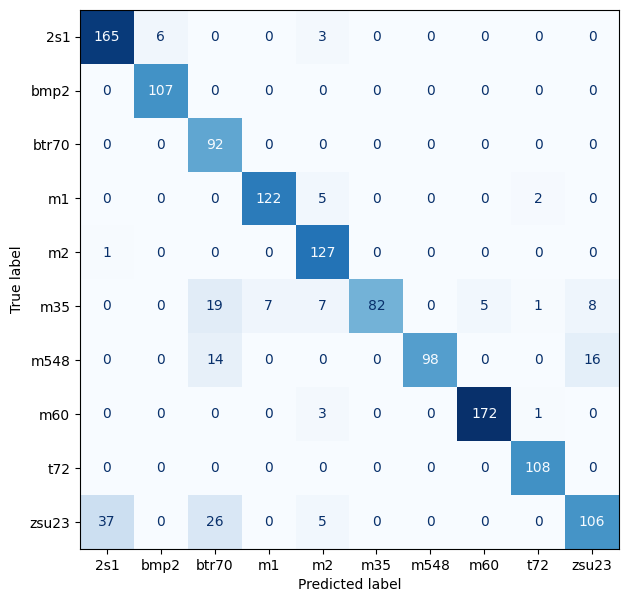

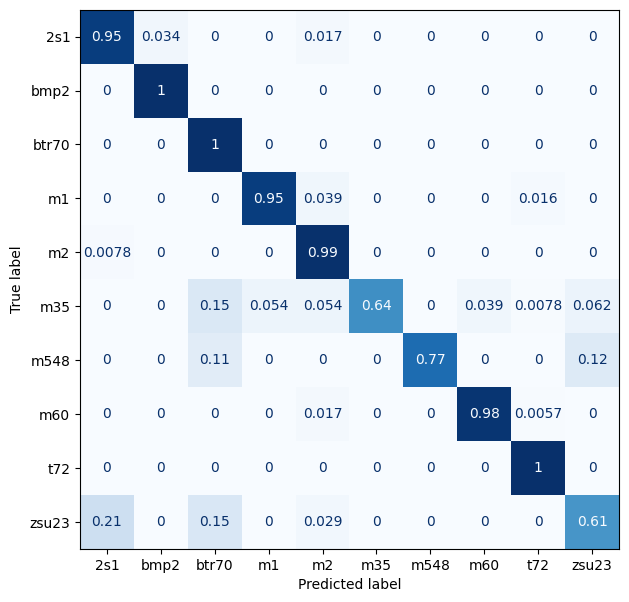

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run5_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(meas_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()
plt.show()

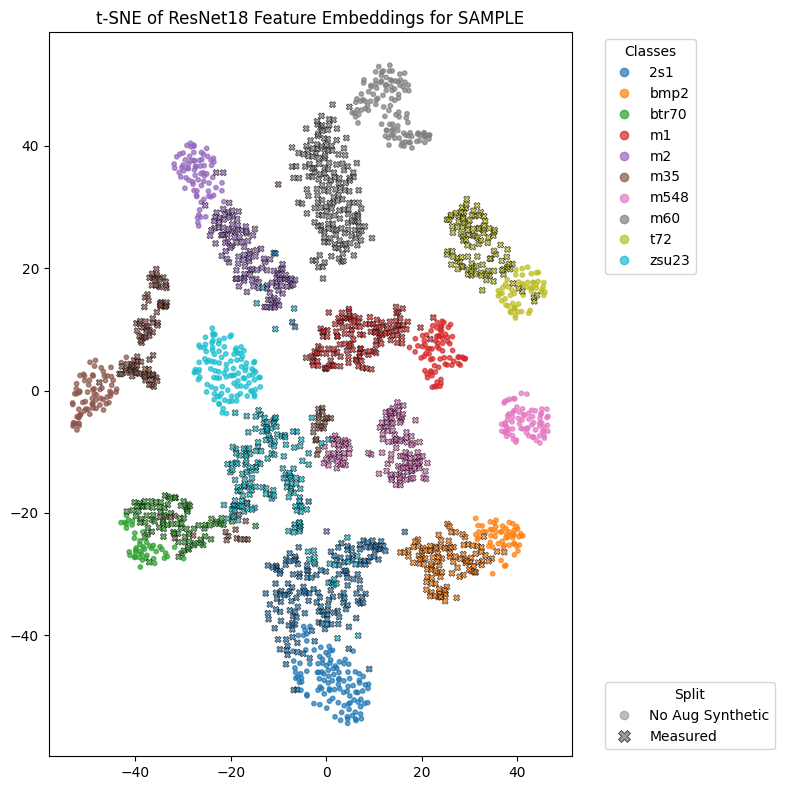

In [9]:
train_plot_ds = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
test_plot_ds = meas_ds

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_plot_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run5_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_plot_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_plot_ds), 0],
    features_2d[:len(train_plot_ds), 1],
    c=labels_list[:len(train_plot_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_plot_ds):, 0],
    features_2d[len(train_plot_ds):, 1],
    c=labels_list[len(train_plot_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-06-20 13:06:00.377] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 25


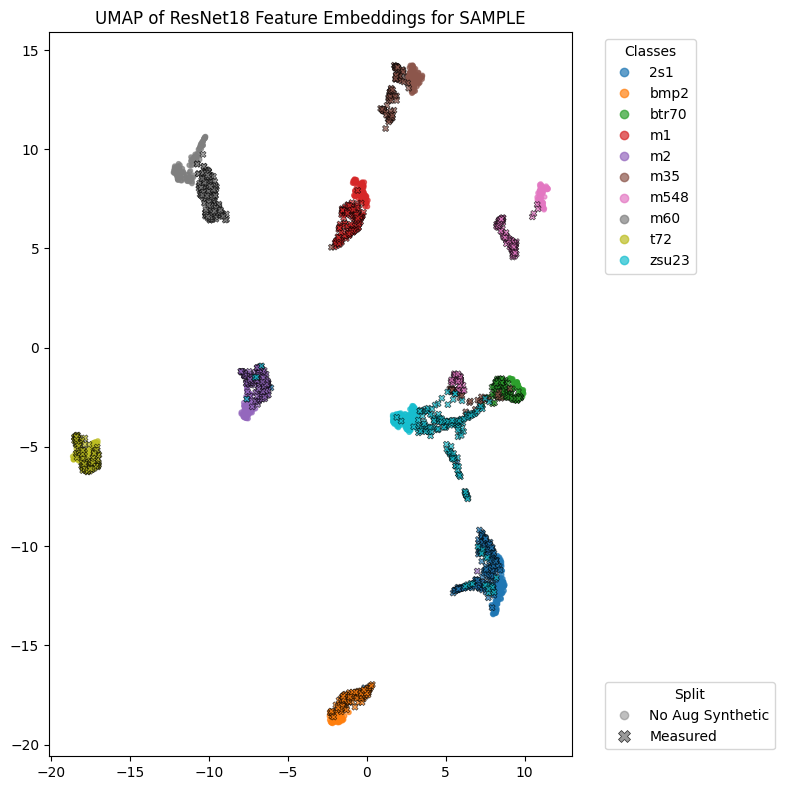

[2026-06-20 13:06:26.636] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 50


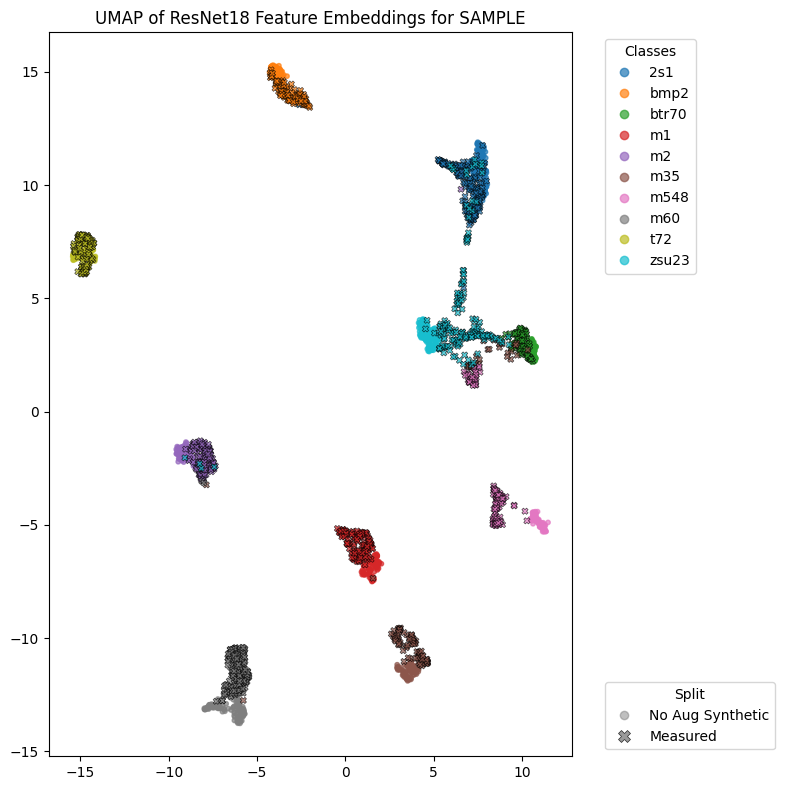

[2026-06-20 13:06:52.643] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 100


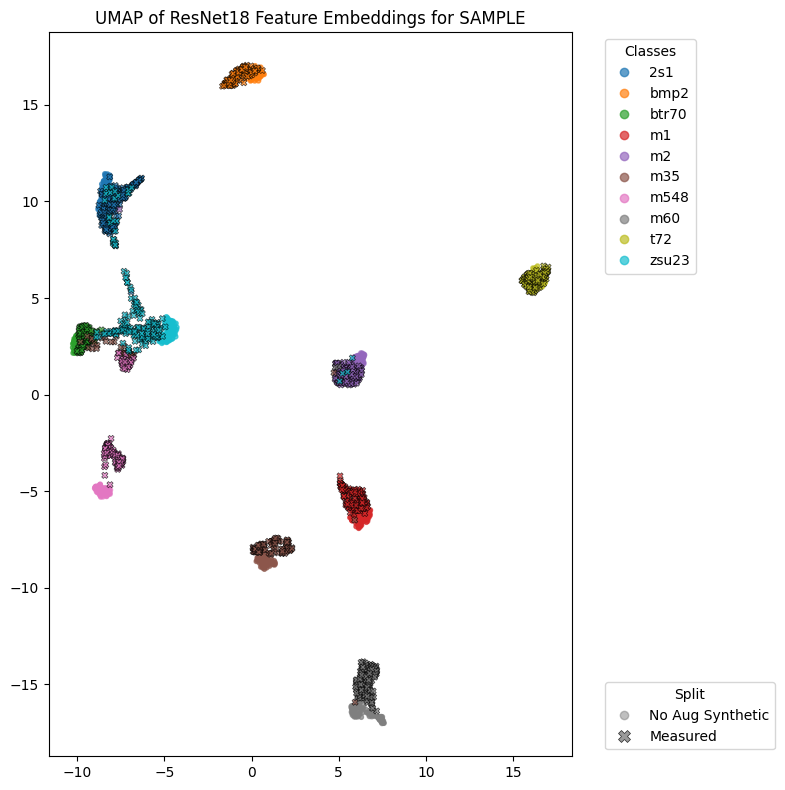

[2026-06-20 13:07:18.641] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 200


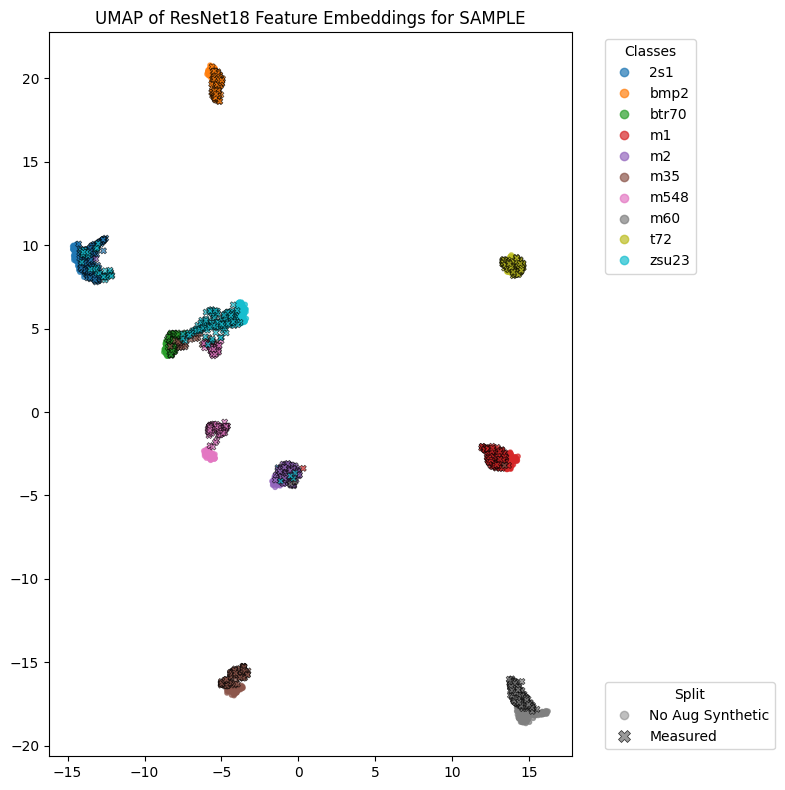

In [10]:
train_plot_ds = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
test_plot_ds = meas_ds

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])

for num in [25, 50, 100, 200]:

    combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

    device = torch.cuda.set_device("cuda:0")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(train_plot_ds.class_to_idx))
        )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_w_noise/rn18_run5_b16.pth"),
        map_location=device
    ))

    new_model = new_model.to(device)
    new_model.eval()

    feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()

    features, labels_list = [], []

    with torch.no_grad():
        for inputs, targets in combined_loader:
            inputs = inputs.to(device)
            feats = feature_extractor(inputs)
            feats = feats.view(feats.size(0), -1)
            features.append(feats.cpu())
            labels_list.append(targets)

    features = torch.cat(features).numpy()
    labels_list = torch.cat(labels_list).numpy()

    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(features)

    # Get class names from the dataset
    class_names = [name for name, idx in sorted(train_plot_ds.class_to_idx.items(), key=lambda x: x[1])]

    n_classes = len(class_names)
    
    print(f"UMAP n_neighbours = {num}")

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(train_plot_ds), 0],
        features_2d_umap[:len(train_plot_ds), 1],
        c=labels_list[:len(train_plot_ds)],
        cmap="tab10",
        s=10,
        alpha=0.7,
        marker = "o",
        vmin=0, vmax=n_classes - 1
    )

    plt.scatter(
        features_2d_umap[len(train_plot_ds):, 0],
        features_2d_umap[len(train_plot_ds):, 1],
        c=labels_list[len(train_plot_ds):],
        cmap="tab10",
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k",
        vmin=0, vmax=n_classes - 1
    )

    class_legend = plt.legend(
        handles=scatter.legend_elements()[0],
        labels=class_names,
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    fig.add_artist(class_legend)  # keep it when adding the second legend

    # Marker legend for train vs test
    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
    plt.tight_layout()
    plt.show()